In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.callbacks import Callback

## Mounting to Google Drive

### Uncomment if utilizing Google Colab

In [2]:
colab = True

In [3]:
path = os.getcwd()
print(path)
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir("./drive/My Drive/TreatmentSystems/Final_Dataset")
else:
    os.chdir(os.path.join(path, 'Final_Dataset'))

print(os.getcwd())

/content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/TreatmentSystems/Final_Dataset


### Receiving Data and Completing Train-Test Split

In [4]:
data = pd.read_csv('concatenated_data.csv')
print(type(data))
print(data.head())

# is_sorted = data.equals(data.sort_values(by=['PatientID', 'time']).reset_index(drop=True))
# print("Data is sorted correctly:", is_sorted)
times = data.pop('time')

data.head()

numPatients = data['PatientID'].max()
print(numPatients)

<class 'pandas.core.frame.DataFrame'>
               time  PatientID  calories  heart_rate  steps  basal_rate  \
0  06-13-2018 18:40          1    6.3595   82.322835     34    0.091667   
1  06-13-2018 18:45          1    7.7280   83.740157      0    0.091667   
2  06-13-2018 18:50          1    4.7495   80.525180      0    0.091667   
3  06-13-2018 18:55          1    6.3595   89.129032     20    0.091667   
4  06-13-2018 19:00          1    5.1520   92.495652      0    0.075000   

   bolus_volume_delivered  glucose  
0                     0.0    332.0  
1                     0.0    326.0  
2                     0.0    330.0  
3                     0.0    324.0  
4                     0.0    306.0  
22


In [5]:
print((data['basal_rate'] >= 0).all() and (data['basal_rate'] <= 1).all())

True


In [6]:
print((data['bolus_volume_delivered'] >= 0).all() and (data['bolus_volume_delivered'] <= 1).all())

False


In [7]:
train_patients = list(range(1, 17))
print(len(train_patients))
print(train_patients)

test_patients = list(range(17, numPatients + 1))
print(len(test_patients))
print(test_patients)

train_data = data[data['PatientID'].isin(train_patients)]
test_data = data[data['PatientID'].isin(test_patients)]

print("\n Training Data:")
train_X, train_y = train_data.loc[:, data.columns != 'glucose'], train_data['glucose']
print(train_X.head())
print(train_y.head())

train_len = len(train_X)
N = len(data)
print(train_len, N)
train_percent = (train_len / N)

print("Percent of Data in Training = ", np.round(train_percent * 100, 2))
print("\n Testing Data:")
test_X, test_y = test_data.loc[:, data.columns != 'glucose'], test_data['glucose']
print(test_X.head())
print(test_y.head())

print("Percent of Data in Testing = ", np.round((1 - train_percent) * 100, 2))

16
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
6
[17, 18, 19, 20, 21, 22]

 Training Data:
   PatientID  calories  heart_rate  steps  basal_rate  bolus_volume_delivered
0          1    6.3595   82.322835     34    0.091667                     0.0
1          1    7.7280   83.740157      0    0.091667                     0.0
2          1    4.7495   80.525180      0    0.091667                     0.0
3          1    6.3595   89.129032     20    0.091667                     0.0
4          1    5.1520   92.495652      0    0.075000                     0.0
0    332.0
1    326.0
2    330.0
3    324.0
4    306.0
Name: glucose, dtype: float64
46080 63360
Percent of Data in Training =  72.73

 Testing Data:
       PatientID  calories  heart_rate  steps  basal_rate  \
46080         17   15.0429   96.371901      8       0.035   
46081         17    8.3164   91.395349      0       0.035   
46082         17    7.5826   85.991935      0       0.035   
46083         17    7.3380   82.434

### Scale the Features Before Training

#### Columns That Needed to Be Scaled:
- Calories
- Steps
- Heart Rate
- Glucose

Possibly Need to Scale the Basal Rate -> First Attempt will be without scaling the Basal

Note that Glucose Needs to be converted back to the original values before the scaling in order to interpret the results

In [8]:
print("Calories:")
print("Min = ", train_X['calories'].min())
print("Max = ", train_X['calories'].max())

print("Heart Rate:")
print("Min = ", train_X['heart_rate'].min())
print("Max = ", train_X['heart_rate'].max())

print("Steps:")
print("Min = ", train_X['steps'].min())
print("Max = ", train_X['steps'].max())

print("Basal Rate:")
print("Min = ", train_X['basal_rate'].min())
print("Max = ", train_X['basal_rate'].max())

Calories:
Min =  4.025000036
Max =  78.85771084
Heart Rate:
Min =  39.38406616
Max =  174.7142857
Steps:
Min =  0
Max =  658
Basal Rate:
Min =  0.0
Max =  0.25


In [9]:
scaler1_x = MinMaxScaler(feature_range=(-1, 1))
scaler1_y = MinMaxScaler(feature_range=(-1, 1))

In [10]:
column_names = data.columns
print(column_names[-3:-1])
print(column_names[:1])
print(column_names[1:data.shape[1] - 3])
# standardize_features = list(column_names[1:data.shape[1] - 3]) # Features to standardize
# passthrough_features = list(column_names[-3:-1]) # Keep these unchanged
# print(standardize_features, passthrough_features)

# Define ColumnTransformer

train_X_scaled = scaler1_x.fit_transform(np.array(train_X)[:, 1:6])
test_X_scaled = scaler1_x.transform(np.array(test_X)[:, 1:6])

print(train_X_scaled[:5], type(train_X_scaled))
print(test_X_scaled[:5], type(test_X_scaled))

Index(['basal_rate', 'bolus_volume_delivered'], dtype='object')
Index(['PatientID'], dtype='object')
Index(['calories', 'heart_rate', 'steps'], dtype='object')
[[-0.9376075  -0.36542232 -0.89665653 -0.26666666 -0.73684211]
 [-0.90103259 -0.34447618 -1.         -0.26666666 -0.73684211]
 [-0.98063681 -0.39198926 -1.         -0.26666666 -0.73684211]
 [-0.9376075  -0.2648358  -0.93920973 -0.26666666 -0.73684211]
 [-0.96987949 -0.21508165 -1.         -0.4        -0.73684211]] <class 'numpy.ndarray'>
[[-0.70553252 -0.15779587 -0.97568389 -0.72       -0.73684211]
 [-0.88530684 -0.23134267 -1.         -0.72       -0.73684211]
 [-0.90491859 -0.31119791 -1.         -0.72       -0.73684211]
 [-0.91145584 -0.36377314 -1.         -0.72       -0.73684211]
 [-0.90491859 -0.4171514  -1.         -0.72       -0.73684211]] <class 'numpy.ndarray'>


In [11]:
print("Glucose")
print("Min = ", train_y.min())
print("Max = ", train_y.max())

Glucose
Min =  40.0
Max =  444.0


In [12]:
train_y_scaled = scaler1_y.fit_transform(np.array(train_y).reshape(-1, 1))
test_y_scaled = scaler1_y.transform(np.array(test_y).reshape(-1, 1))

print(train_y_scaled[:5])
print(test_y_scaled[:5])

[[0.44554455]
 [0.41584158]
 [0.43564356]
 [0.40594059]
 [0.31683168]]
[[-1.        ]
 [-0.99339934]
 [-0.98679868]
 [-0.98019802]
 [-0.95049505]]


In [13]:
sequence_length, batch_size = 50, 64
n_features = 5
stride = 1

train_gen = TimeseriesGenerator(train_X_scaled, train_y_scaled, length=sequence_length, batch_size = batch_size, stride = stride)
test_gen = TimeseriesGenerator(test_X_scaled, test_y_scaled, length=sequence_length, batch_size=batch_size, stride = stride)

In [14]:
print(type(train_gen))
print(type(test_gen))

print(len(train_gen))
print(train_gen[0])

x, y = train_gen[0]

print(x.shape)
print(y.shape)

<class 'keras.src.legacy.preprocessing.sequence.TimeseriesGenerator'>
<class 'keras.src.legacy.preprocessing.sequence.TimeseriesGenerator'>
720
(array([[[-0.9376075 , -0.36542232, -0.89665653, -0.26666666,
         -0.73684211],
        [-0.90103259, -0.34447618, -1.        , -0.26666666,
         -0.73684211],
        [-0.98063681, -0.39198926, -1.        , -0.26666666,
         -0.73684211],
        ...,
        [-0.99139414, -0.23954998, -1.        , -1.        ,
         -0.73684211],
        [-0.99784853, -0.31170494, -1.        , -1.        ,
         -0.73684211],
        [-1.        , -0.41452938, -1.        , -1.        ,
         -0.73684211]],

       [[-0.90103259, -0.34447618, -1.        , -0.26666666,
         -0.73684211],
        [-0.98063681, -0.39198926, -1.        , -0.26666666,
         -0.73684211],
        [-0.9376075 , -0.2648358 , -0.93920973, -0.26666666,
         -0.73684211],
        ...,
        [-0.99784853, -0.31170494, -1.        , -1.        ,
         -

In [16]:
model1 = Sequential()
model1.add(LSTM(100, activation='relu', input_shape=(sequence_length, n_features)))
model1.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=1e-3)
model1.compile(loss='mse', optimizer = adam_opt)

# fit model
history = model1.fit(train_gen, validation_data=test_gen, epochs = 50, verbose=2)

preds = model1.predict(test_gen)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


720/720 - 14s - 19ms/step - loss: 0.9574 - val_loss: 0.0914
Epoch 2/50
720/720 - 14s - 19ms/step - loss: 9849.0586 - val_loss: 0.0896
Epoch 3/50
720/720 - 6s - 9ms/step - loss: 0.1211 - val_loss: 0.0850
Epoch 4/50
720/720 - 10s - 14ms/step - loss: 0.1579 - val_loss: 0.0939
Epoch 5/50
720/720 - 6s - 8ms/step - loss: 0.1191 - val_loss: 0.0931
Epoch 6/50
720/720 - 6s - 8ms/step - loss: 0.1188 - val_loss: 0.0901
Epoch 7/50
720/720 - 6s - 8ms/step - loss: 0.1181 - val_loss: 0.0882
Epoch 8/50
720/720 - 12s - 16ms/step - loss: 0.1171 - val_loss: 0.0890
Epoch 9/50
720/720 - 6s - 8ms/step - loss: 0.1165 - val_loss: 0.0957
Epoch 10/50
720/720 - 7s - 10ms/step - loss: 0.1162 - val_loss: 0.0877
Epoch 11/50
720/720 - 6s - 8ms/step - loss: 0.1158 - val_loss: 0.0956
Epoch 12/50
720/720 - 8s - 11ms/step - loss: 0.1151 - val_loss: 0.1007
Epoch 13/50
720/720 - 6s - 8ms/step - loss: 0.1150 - val_loss: 0.0933
Epoch 14/50
720/720 - 7s - 10ms/step - loss: 0.1141 - val_loss: 0.0822
Epoch 15/50
720/720 - 6s -

In [17]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

[[161.83376]
 [161.80127]
 [161.82861]
 ...
 [157.55539]
 [157.55078]
 [157.2186 ]]
[[144.        ]
 [149.3333333 ]
 [154.6666667 ]
 ...
 [ 95.66666667]
 [ 98.33333333]
 [101.        ]]
R2 Score =  -0.2853265765665587


### Creation of Plots for Visualizations

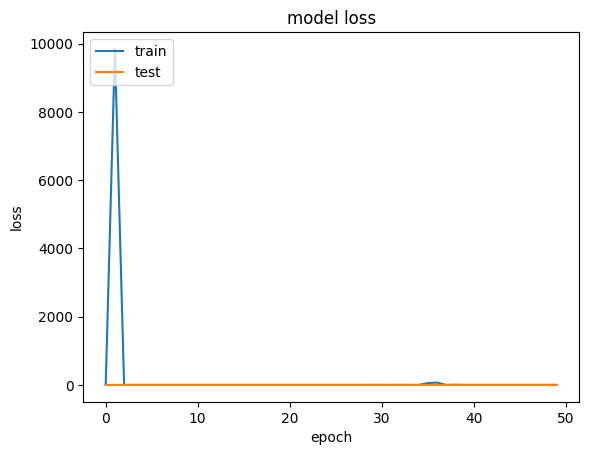

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Model 2: Deep LSTM with Dropout

In [ ]:
model2 = Sequential()
#Layer 1
model2.add(LSTM(256, activation='relu', return_sequences= True, input_shape=(sequence_length, n_features)))
model2.add(Dropout(0.3))

#Layer 2
model2.add(LSTM(128, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.25))

#Layer 2
model2.add(LSTM(64, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(32, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.15))

#Layer 2
model2.add(LSTM(16, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.1))

model2.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(loss='mse', optimizer = adam_opt)

# fit model
history2 = model2.fit(train_gen, validation_data=test_gen, epochs = 100, verbose=2, shuffle = False)

preds = model2.predict(test_gen)
preds = preds.reshape(-1, 1)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

In [ ]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Scalar Modifications in Min-Max Scalar

Made modifications to scaling such that each patient is seperately scaled

In [ ]:
scaled_X = []
scaled_y = []

# Scale the training data (as shown previously)
for patient_id in range(1, 17):
    # Get patient-specific data (assuming data contains 'PatientID')
    patient_data = data[data['PatientID'] == patient_id]
    
    # Separate features (X) and target (y)
    patient_X = patient_data.drop(columns=['glucose', 'PatientID'])
    patient_y = patient_data['glucose']
    
    # Scale features for this patient
    patient_X_scaled = scaler1_x.fit_transform(patient_X)  # Fit and transform for training
    # Scale target for this patient
    patient_y_scaled = scaler1_y.fit_transform(patient_y.values.reshape(-1, 1))  # Fit and transform for training
    
    # Append scaled data to lists
    scaled_X.append(patient_X_scaled)
    scaled_y.append(patient_y_scaled)

# Concatenate the scaled data for all patients
train_X_scaled = np.concatenate(scaled_X, axis=0)
train_y_scaled = np.concatenate(scaled_y, axis=0)

In [ ]:
# For Test Data
test_scaled_X = []
test_scaled_y = []

for patient_id in range(17, numPatients + 1):
    # Get patient-specific data (assuming data contains 'PatientID')
    patient_data = data[data['PatientID'] == patient_id]
    
    # Separate features (X) and target (y)
    patient_X = patient_data.drop(columns=['glucose', 'PatientID'])
    patient_y = patient_data['glucose']
    
    # Use the already fitted scaler to transform the test data
    patient_X_scaled = scaler1_x.transform(patient_X)
    patient_y_scaled = scaler1_y.transform(patient_y.values.reshape(-1, 1))
    
    # Append scaled data to lists
    test_scaled_X.append(patient_X_scaled)
    test_scaled_y.append(patient_y_scaled)

# Concatenate the scaled test data
test_X_scaled = np.concatenate(test_scaled_X, axis=0)
test_y_scaled = np.concatenate(test_scaled_y, axis=0)